# Mediapipe: Holistic 

# 1. Importazione e installazione delle dipendenze

In [11]:
!pip install mediapipe==0.10.14 opencv-python numpy psutil pandas openpyxl

  Using cached protobuf-4.25.9-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-macosx_10_9_universal2.whl (394 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3


In [1]:
import mediapipe as mp 
import cv2
import os 
import psutil
import time
import numpy as np
import pandas as pd
import platform
import glob
import matplotlib.pyplot as plt 

In [2]:
print(f"Mediapipe version: {mp.__version__}")
print(f"CPU: {platform.processor()}")
print(f"RAM totale: {psutil.virtual_memory().total / 1e9:.1f} GB")

Mediapipe version: 0.10.14
CPU: arm
RAM totale: 8.6 GB


# 2. Importazione drawing utilities da holistic model

In [3]:
mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic

# 3. Pipeline

La pipeline è la sequenza di operazioni che ogni frame attraversa, dall'input grezzo fino al salvataggio delle metriche.
Ogni stage è una funzione separata, il Main le chiama in ordine.

> **Differenza rispetto agli altri modelli:** MediaPipe Holistic non richiede un resize esplicito né un cast del tensore, riceve direttamente il frame RGB. Il modello vive dentro un context manager `with mp_holistic.Holistic(...) as holistic`, quindi le funzioni di pipeline ricevono l'istanza `holistic` come parametro. Il rendering disegna **4 componenti separati**: face, right hand, left hand, pose, sia sul frame originale che sullo schermo nero.

## 4. Pre-processing
Converte il frame `BGR` in `RGB`, che è il formato atteso da MediaPipe.
- A differenza dei modelli su base TensorFlow, non avviene nessun resize esplicito: **MediaPipe gestisce internamente le dimensioni**

In [4]:
def pre_processing(frame):
    # BGR → RGB
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return image

## 5. Inferenze
Passiamo il frame RGB al modello Holistic che restituisce i risultati.
- `results` contiene: `face_landmarks`, `pose_landmarks`, `left_hand_landmarks`, `right_hand_landmarks`
- Dopo la detection, il frame viene riconvertito in BGR per il rendering con OpenCV

In [5]:
def make_detections(holistic, image):
    results = holistic.process(image)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

## 6. Post-processing
Calcola le metriche di qualità del rilevamento:
- **`n_pose_landmarks`**: numero di landmark di posa rilevati (0 se nessuna persona trovata)
- **`conf_mean`**:  confidenza media su tutti i 17 keypoint → proxy dell'accuratezza del rilevamento (MediaPipe espone `visibility` come score)
- **`jitter`**: distanza media tra la posizione dei keypoint al frame `t` e al frame `t-1`, consentendo di misurare la stabilità del tracking

In [6]:
def post_processing(results, prev_results=None):
    # Numero di pose landmarks rilevati
    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark
        n_pose_landmarks = len(landmarks)
        # Visibility come proxy della confidenza (MediaPipe usa visibility invece di score)
        conf_mean = round(float(np.mean([lm.visibility for lm in landmarks])), 4)
        # Jitter: distanza media rispetto al frame precedente
        if prev_results is not None and prev_results.pose_landmarks:
            prev_landmarks = prev_results.pose_landmarks.landmark
            curr_coords = np.array([[lm.x, lm.y] for lm in landmarks])
            prev_coords = np.array([[lm.x, lm.y] for lm in prev_landmarks])
            jitter = round(float(np.abs(curr_coords - prev_coords).mean()), 4)
        else:
            jitter = 0.0
    else:
        n_pose_landmarks = 0
        conf_mean        = 0.0
        jitter           = 0.0

    return {
        'n_pose_landmarks': n_pose_landmarks,
        'conf_mean':        conf_mean,
        'jitter':           jitter,
    }


## 7. Rendering
Disegna i 4 componenti (face, right hand, left hand, pose) sia sul frame originale che sullo schermo nero,
poi li affianca con `np.hstack`.

In [7]:
def rendering(image, results, fps, cpu_usage, ram_usage, run, video_name):
    black_screen = np.zeros(image.shape, dtype=np.uint8)

    # Disegniamo lo scheletro nello schermo nero
    # Disegniamo i face landmarks
    mp_drawing.draw_landmarks(black_screen, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS,
                      mp_drawing.DrawingSpec(color=(80,110,10), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(80,256,121), thickness=2, circle_radius=2))
    # Mano destra
    mp_drawing.draw_landmarks(black_screen, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
    # Mano sinistra
    mp_drawing.draw_landmarks(black_screen, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
    # Pose Detections
    mp_drawing.draw_landmarks(black_screen, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))

    # Disegniamo ora lo scheletro sul video
    # Face Landmarks 
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS,
                      mp_drawing.DrawingSpec(color=(80,110,10), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(80,256,121), thickness=2, circle_radius=2))
    # Mano destra
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
    # Mano sinistra
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
    # Pose Detections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                      mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                      mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))

    # Unione delle immagini
    combined_image = np.hstack((image, black_screen))

    # cv2.putText per vedere nel video
    cv2.putText(combined_image, f"CPU: {cpu_usage}%",          (10,  30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
    cv2.putText(combined_image, f"RAM: {ram_usage:.1f} MB",    (10,  70), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
    cv2.putText(combined_image, f"FPS: {int(fps)}",            (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
    cv2.putText(combined_image, f"Video: {video_name[:15]}...", (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 2)
    cv2.putText(combined_image, f"Run: {run+1}/2",             (10, 190), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)

    return combined_image

## 8. Raccolta metriche
Raccoglie tutte le metriche del frame in un dizionario. 
Ogni chiamata produce una riga dell'Excel finale.

In [8]:
def collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data):
    return {
        "Video name":       video_name,
        "Execution":        run + 1,
        "Frame N":          frame_count,
        "CPU (%)":          cpu_usage,
        "RAM (MB)":         round(ram_usage, 2),
        "FPS":              round(fps, 2),
        "Confidence":       post_data['conf_mean'],
        "Pose landmarks":   post_data['n_pose_landmarks'],
        "Jitter":           post_data['jitter'],
    }

## 9. Main (Fase di detection)

In [9]:
video_folder = "/Users/rebeccaspigacortes/Desktop/data_set_singolo"
video_paths  = sorted(glob.glob(video_folder + "/*.mp4"))

process      = psutil.Process(os.getpid())
project_data = []

# Doppio ciclo 
for video_path in video_paths:
    video_name = os.path.basename(video_path)
    print(f"\n{'='*40}")
    print(f"Processo: {video_name}")

    for run in range(2):
        print(f"Sto riproducendo: {video_name} | Esecuzione: {run + 1}/2")

        cap         = cv2.VideoCapture(video_path)
        frame_count = 0
        prev_time   = 0
        prev_results = None  # per il calcolo del jitter

        # Initiate holistic model
        with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break  # Se il video finisce, esce dal while
                frame_count += 1

                # FPS
                curr_time = time.perf_counter()
                if prev_time != 0:
                    frame_time = curr_time - prev_time
                    fps = 1 / frame_time
                else:
                    fps = 0

                # chiediamo a psutil i dati per la CPU e per la RAM
                cpu_usage = psutil.cpu_percent()
                ram_usage = process.memory_info().rss / (1024 * 1024)
                prev_time = curr_time

                image                 = pre_processing(frame)                               # Stage 1
                image, results        = make_detections(holistic, image)                    # Stage 2
                post_data             = post_processing(results, prev_results)              # Stage 3
                combined_image        = rendering(image, results,                           # Stage 4
                                                  fps, cpu_usage, ram_usage, run, video_name)
                project_data.append(collect_metrics(video_name, run, frame_count,          # Stage 5
                                                    fps, cpu_usage, ram_usage, post_data))

                prev_results = results  # salva per il jitter al prossimo frame

                # print per vedere i risulatati nella CONSOLE
                print(f"CPU: {cpu_usage}% | RAM: {ram_usage:.2f}MB | FPS: {fps:.1f}")
                cv2.imshow('Holistic Model Detections with Skeleton Rendering', combined_image)
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

        cap.release()
        cv2.destroyAllWindows()


Processo: 01-jumping-lady.mp4
Sto riproducendo: 01-jumping-lady.mp4 | Esecuzione: 1/2


I0000 00:00:1776618386.266842 18232278 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776618386.400244 18234180 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618386.412562 18234180 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618386.414071 18234179 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618386.414076 18234178 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618386.414535 18234181 inference_feedback_manager.cc:114] Feedback manager requires

CPU: 31.2% | RAM: 484.66MB | FPS: 0.0
CPU: 68.9% | RAM: 851.95MB | FPS: 1.8
CPU: 81.0% | RAM: 878.41MB | FPS: 3.4
CPU: 71.2% | RAM: 715.67MB | FPS: 4.3
CPU: 49.7% | RAM: 788.70MB | FPS: 5.1
CPU: 52.0% | RAM: 765.55MB | FPS: 4.5
CPU: 51.2% | RAM: 805.08MB | FPS: 4.9
CPU: 47.7% | RAM: 816.28MB | FPS: 5.2
CPU: 38.6% | RAM: 825.17MB | FPS: 5.5
CPU: 34.0% | RAM: 841.17MB | FPS: 5.5
CPU: 44.2% | RAM: 846.19MB | FPS: 5.4
CPU: 31.7% | RAM: 855.31MB | FPS: 5.5
CPU: 36.8% | RAM: 856.34MB | FPS: 5.5
CPU: 39.0% | RAM: 859.67MB | FPS: 5.5
CPU: 30.3% | RAM: 852.16MB | FPS: 5.4
CPU: 29.4% | RAM: 866.81MB | FPS: 5.4
CPU: 38.5% | RAM: 867.91MB | FPS: 5.5
CPU: 42.4% | RAM: 871.23MB | FPS: 5.5
CPU: 31.5% | RAM: 871.47MB | FPS: 5.4
CPU: 33.8% | RAM: 872.50MB | FPS: 5.5
CPU: 42.4% | RAM: 875.53MB | FPS: 5.5
CPU: 39.2% | RAM: 875.64MB | FPS: 5.4
CPU: 40.8% | RAM: 876.23MB | FPS: 5.4
CPU: 39.6% | RAM: 878.05MB | FPS: 5.5
CPU: 44.4% | RAM: 879.72MB | FPS: 5.5
CPU: 49.3% | RAM: 879.61MB | FPS: 5.5
CPU: 37.8% |

I0000 00:00:1776618433.696613 18232278 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776618433.809608 18235584 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618433.820517 18235589 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618433.821945 18235583 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618433.821947 18235588 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776618433.822490 18235585 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling su

CPU: 39.0% | RAM: 988.48MB | FPS: 0.0
CPU: 56.3% | RAM: 930.22MB | FPS: 3.1
CPU: 40.7% | RAM: 1010.12MB | FPS: 3.4
CPU: 32.7% | RAM: 1042.72MB | FPS: 5.3
CPU: 37.9% | RAM: 1033.31MB | FPS: 5.2
CPU: 31.4% | RAM: 963.27MB | FPS: 5.2
CPU: 30.1% | RAM: 1034.06MB | FPS: 5.4
CPU: 36.2% | RAM: 1035.16MB | FPS: 5.4
CPU: 49.7% | RAM: 940.12MB | FPS: 5.3
CPU: 27.8% | RAM: 975.50MB | FPS: 5.5
CPU: 27.9% | RAM: 980.17MB | FPS: 5.5
CPU: 27.8% | RAM: 984.75MB | FPS: 5.5
CPU: 29.7% | RAM: 976.98MB | FPS: 5.4
CPU: 26.8% | RAM: 982.97MB | FPS: 5.5
CPU: 26.7% | RAM: 984.38MB | FPS: 5.5
CPU: 26.2% | RAM: 990.33MB | FPS: 5.5
CPU: 31.3% | RAM: 986.58MB | FPS: 5.4
CPU: 26.4% | RAM: 987.28MB | FPS: 5.5
CPU: 26.2% | RAM: 987.75MB | FPS: 5.5
CPU: 29.3% | RAM: 981.66MB | FPS: 5.4
CPU: 30.4% | RAM: 988.42MB | FPS: 5.2
CPU: 25.7% | RAM: 990.09MB | FPS: 5.5
CPU: 26.9% | RAM: 990.38MB | FPS: 5.5
CPU: 24.5% | RAM: 988.61MB | FPS: 5.4
CPU: 31.5% | RAM: 967.20MB | FPS: 5.4
CPU: 25.7% | RAM: 989.34MB | FPS: 5.4
CPU: 33

...

CPU: 43.9% | RAM: 661.53MB | FPS: 0.0
CPU: 39.4% | RAM: 731.14MB | FPS: 7.6
CPU: 44.1% | RAM: 668.61MB | FPS: 13.4
CPU: 43.9% | RAM: 676.55MB | FPS: 13.7
CPU: 35.9% | RAM: 629.52MB | FPS: 13.1
CPU: 36.2% | RAM: 627.11MB | FPS: 13.7
CPU: 35.6% | RAM: 631.28MB | FPS: 13.2
CPU: 0.0% | RAM: 634.92MB | FPS: 14.6
CPU: 0.0% | RAM: 635.53MB | FPS: 13.8
CPU: 0.0% | RAM: 639.62MB | FPS: 14.2
CPU: 36.0% | RAM: 640.08MB | FPS: 13.7
CPU: 53.4% | RAM: 619.77MB | FPS: 13.9
CPU: 44.3% | RAM: 624.38MB | FPS: 13.3
CPU: 37.3% | RAM: 627.81MB | FPS: 13.5
CPU: 0.0% | RAM: 628.19MB | FPS: 13.8
CPU: 0.0% | RAM: 629.19MB | FPS: 13.9
CPU: 0.0% | RAM: 629.20MB | FPS: 13.7
CPU: 0.0% | RAM: 629.47MB | FPS: 13.7
CPU: 0.0% | RAM: 636.41MB | FPS: 13.7
CPU: 0.0% | RAM: 636.42MB | FPS: 13.8
CPU: 0.0% | RAM: 636.66MB | FPS: 14.0
CPU: 0.0% | RAM: 636.67MB | FPS: 13.7
CPU: 0.0% | RAM: 639.05MB | FPS: 13.7
CPU: 0.0% | RAM: 645.36MB | FPS: 13.7
CPU: 34.7% | RAM: 649.61MB | FPS: 13.6
CPU: 30.2% | RAM: 649.61MB | FPS: 13.9
C

I0000 00:00:1776619491.491029 18232278 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776619491.549281 18252532 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619491.556043 18252530 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619491.556669 18252530 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619491.556708 18252532 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619491.557268 18252535 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling su

CPU: 0.0% | RAM: 669.00MB | FPS: 7.6
CPU: 0.0% | RAM: 624.52MB | FPS: 16.1
CPU: 0.0% | RAM: 622.70MB | FPS: 16.3
CPU: 0.0% | RAM: 613.27MB | FPS: 16.3
CPU: 38.5% | RAM: 611.59MB | FPS: 16.5
CPU: 50.0% | RAM: 561.17MB | FPS: 14.4
CPU: 0.0% | RAM: 560.08MB | FPS: 15.3
CPU: 0.0% | RAM: 561.09MB | FPS: 16.4
CPU: 0.0% | RAM: 563.50MB | FPS: 16.3
CPU: 0.0% | RAM: 562.22MB | FPS: 16.0
CPU: 0.0% | RAM: 568.27MB | FPS: 14.7
CPU: 0.0% | RAM: 568.27MB | FPS: 16.5
CPU: 0.0% | RAM: 571.38MB | FPS: 15.8
CPU: 0.0% | RAM: 570.77MB | FPS: 15.9
CPU: 0.0% | RAM: 570.77MB | FPS: 16.1
CPU: 0.0% | RAM: 573.88MB | FPS: 16.3
CPU: 0.0% | RAM: 573.89MB | FPS: 16.3
CPU: 0.0% | RAM: 575.69MB | FPS: 16.0
CPU: 0.0% | RAM: 575.69MB | FPS: 16.5
CPU: 0.0% | RAM: 575.80MB | FPS: 16.4
CPU: 52.4% | RAM: 576.06MB | FPS: 16.8
CPU: 32.0% | RAM: 576.06MB | FPS: 16.2
CPU: 29.5% | RAM: 576.11MB | FPS: 16.4
CPU: 42.0% | RAM: 576.11MB | FPS: 16.1
CPU: 31.2% | RAM: 576.14MB | FPS: 16.5
CPU: 39.6% | RAM: 576.14MB | FPS: 16.1
CPU: 

I0000 00:00:1776619513.494112 18232278 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1776619513.555140 18252839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619513.562243 18252839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619513.563741 18252842 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619513.564135 18252840 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776619513.564338 18252839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling su

CPU: 0.0% | RAM: 524.47MB | FPS: 0.0
CPU: 32.1% | RAM: 565.09MB | FPS: 7.3
CPU: 46.3% | RAM: 516.20MB | FPS: 15.6
CPU: 30.4% | RAM: 521.08MB | FPS: 16.4
CPU: 31.9% | RAM: 523.88MB | FPS: 16.6
CPU: 32.7% | RAM: 523.34MB | FPS: 16.5
CPU: 36.5% | RAM: 524.69MB | FPS: 15.5
CPU: 0.0% | RAM: 524.75MB | FPS: 16.7
CPU: 0.0% | RAM: 524.92MB | FPS: 16.6
CPU: 0.0% | RAM: 525.02MB | FPS: 16.7
CPU: 0.0% | RAM: 528.33MB | FPS: 16.5
CPU: 0.0% | RAM: 528.47MB | FPS: 16.1
CPU: 0.0% | RAM: 528.47MB | FPS: 16.9
CPU: 0.0% | RAM: 528.47MB | FPS: 16.6
CPU: 0.0% | RAM: 528.47MB | FPS: 16.6
CPU: 0.0% | RAM: 528.47MB | FPS: 16.4
CPU: 0.0% | RAM: 528.69MB | FPS: 16.5
CPU: 0.0% | RAM: 528.75MB | FPS: 16.4
CPU: 31.0% | RAM: 528.75MB | FPS: 16.6
CPU: 33.3% | RAM: 528.75MB | FPS: 16.4
CPU: 27.7% | RAM: 528.75MB | FPS: 16.6
CPU: 31.9% | RAM: 528.75MB | FPS: 16.5
CPU: 32.7% | RAM: 528.75MB | FPS: 16.5
CPU: 0.0% | RAM: 528.84MB | FPS: 16.4
CPU: 0.0% | RAM: 530.53MB | FPS: 16.4
CPU: 0.0% | RAM: 530.73MB | FPS: 16.5
CPU

# 10. Export dati → Excel
Salva `project_data` in un file `.xlsx`.

In [10]:
df = pd.DataFrame(project_data)

excel_name = f"results_mediapipe_holistic_{platform.node()}.xlsx"
df.to_excel(excel_name, index=False)

print(f"Salvato: {excel_name}")
print(df.describe().round(3))


Salvato: results_mediapipe_holistic_MACBOOKAIR-2547.station.xlsx
       Execution    Frame N    CPU (%)   RAM (MB)        FPS  Confidence  \
count    15030.0  15030.000  15030.000  15030.000  15030.000   15030.000   
mean         1.5    199.329     15.889    601.633     13.874       0.844   
std          0.5    138.402     19.034     95.614      3.042       0.208   
min          1.0      1.000      0.000    357.080      0.000       0.000   
25%          1.0     90.000      0.000    547.418     11.930       0.823   
50%          1.5    179.000      0.000    597.230     13.900       0.898   
75%          2.0    271.750     34.200    636.730     15.060       0.955   
max          2.0    577.000     83.500   1042.720     33.670       0.994   

       Pose landmarks     Jitter  
count       15030.000  15030.000  
mean           31.358      0.007  
std             7.177      0.010  
min             0.000      0.000  
25%            33.000      0.001  
50%            33.000      0.004  
75%  

# 11. Analisi stabilità tra i due run
Confronta le metriche medie del run 1 e del run 2.
Un modello stabile produce valori simili in entrambe le esecuzioni sullo stesso video.

In [11]:
summary = df.groupby("Execution")[["FPS", "CPU (%)", "RAM (MB)",
                                    "Confidence", "Jitter"]].mean().round(3)
print(summary)
print("\nDelta run1 vs run2:")
print((summary.loc[2] - summary.loc[1]).round(3))

              FPS  CPU (%)  RAM (MB)  Confidence  Jitter
Execution                                               
1          13.857   16.168   608.966       0.844   0.007
2          13.891   15.610   594.301       0.844   0.007

Delta run1 vs run2:
FPS            0.034
CPU (%)       -0.558
RAM (MB)     -14.665
Confidence     0.000
Jitter         0.000
dtype: float64


# 14. Cella di RIEPILOGO

In [12]:
print(f"{'='*40}")
print(f"RIEPILOGO ESECUZIONE")
print(f"{'='*40}")
print(f"Video processati:        {df['Video name'].nunique()}")
print(f"Frame totali analizzati: {len(df)}")
print(f"Esecuzioni per video:    {df['Execution'].max()}")
print(f"Frame totali (run x2):   {len(df)}")
print(f"\nVideo inclusi nel test:")
for v in sorted(df['Video name'].unique()):
    n_frames = len(df[df['Video name'] == v]) // int(df['Execution'].max())
    print(f"  - {v}  ({n_frames} frame/run)")

RIEPILOGO ESECUZIONE
Video processati:        21
Frame totali analizzati: 15030
Esecuzioni per video:    2
Frame totali (run x2):   15030

Video inclusi nel test:
  - 01-jumping-lady.mp4  (250 frame/run)
  - 02-running-lady.mp4  (290 frame/run)
  - 03-slam-guy.mp4  (267 frame/run)
  - 04-football-guy.mp4  (290 frame/run)
  - 05-warm-up-lady.mp4  (302 frame/run)
  - 06-kpop-cover.mp4  (301 frame/run)
  - 07-workout1.mp4  (577 frame/run)
  - 08-workout2.mp4  (569 frame/run)
  - 09-muay-thai-lady.mp4  (241 frame/run)
  - 10-shadow-box.mp4  (284 frame/run)
  - 11-skill.mp4  (304 frame/run)
  - 12-gym-girl.mp4  (276 frame/run)
  - 13-swim.mp4  (543 frame/run)
  - 14-skill2.mp4  (301 frame/run)
  - 15-roller.mp4  (302 frame/run)
  - 16-multipose1.mp4  (301 frame/run)
  - 17-multipose2.mp4  (290 frame/run)
  - 18-multipose3.mp4  (574 frame/run)
  - 19-multipose4.mp4  (572 frame/run)
  - 20-multipose5.mp4  (322 frame/run)
  - 21-extra.mp4  (359 frame/run)


# 15. Grafici

Creiamo due grafici: 
- **metrics_mean_overview.png**
  > mostrerà la media per video di FPS, CPU, RAM, Confidence, People det e
    Jitter, attraverso un grafico a barre per ogni metrica. Sarà utile per
    confrontare le prestazioni del modello sui diversi video.

- **run_comparison.png**
  > confronterà i valori medi del Run 1 e Run 2 per ogni metrica, in un              grafico a barre. Sarà utile per verificare la stabilità del modello tra le       due esecuzioni 

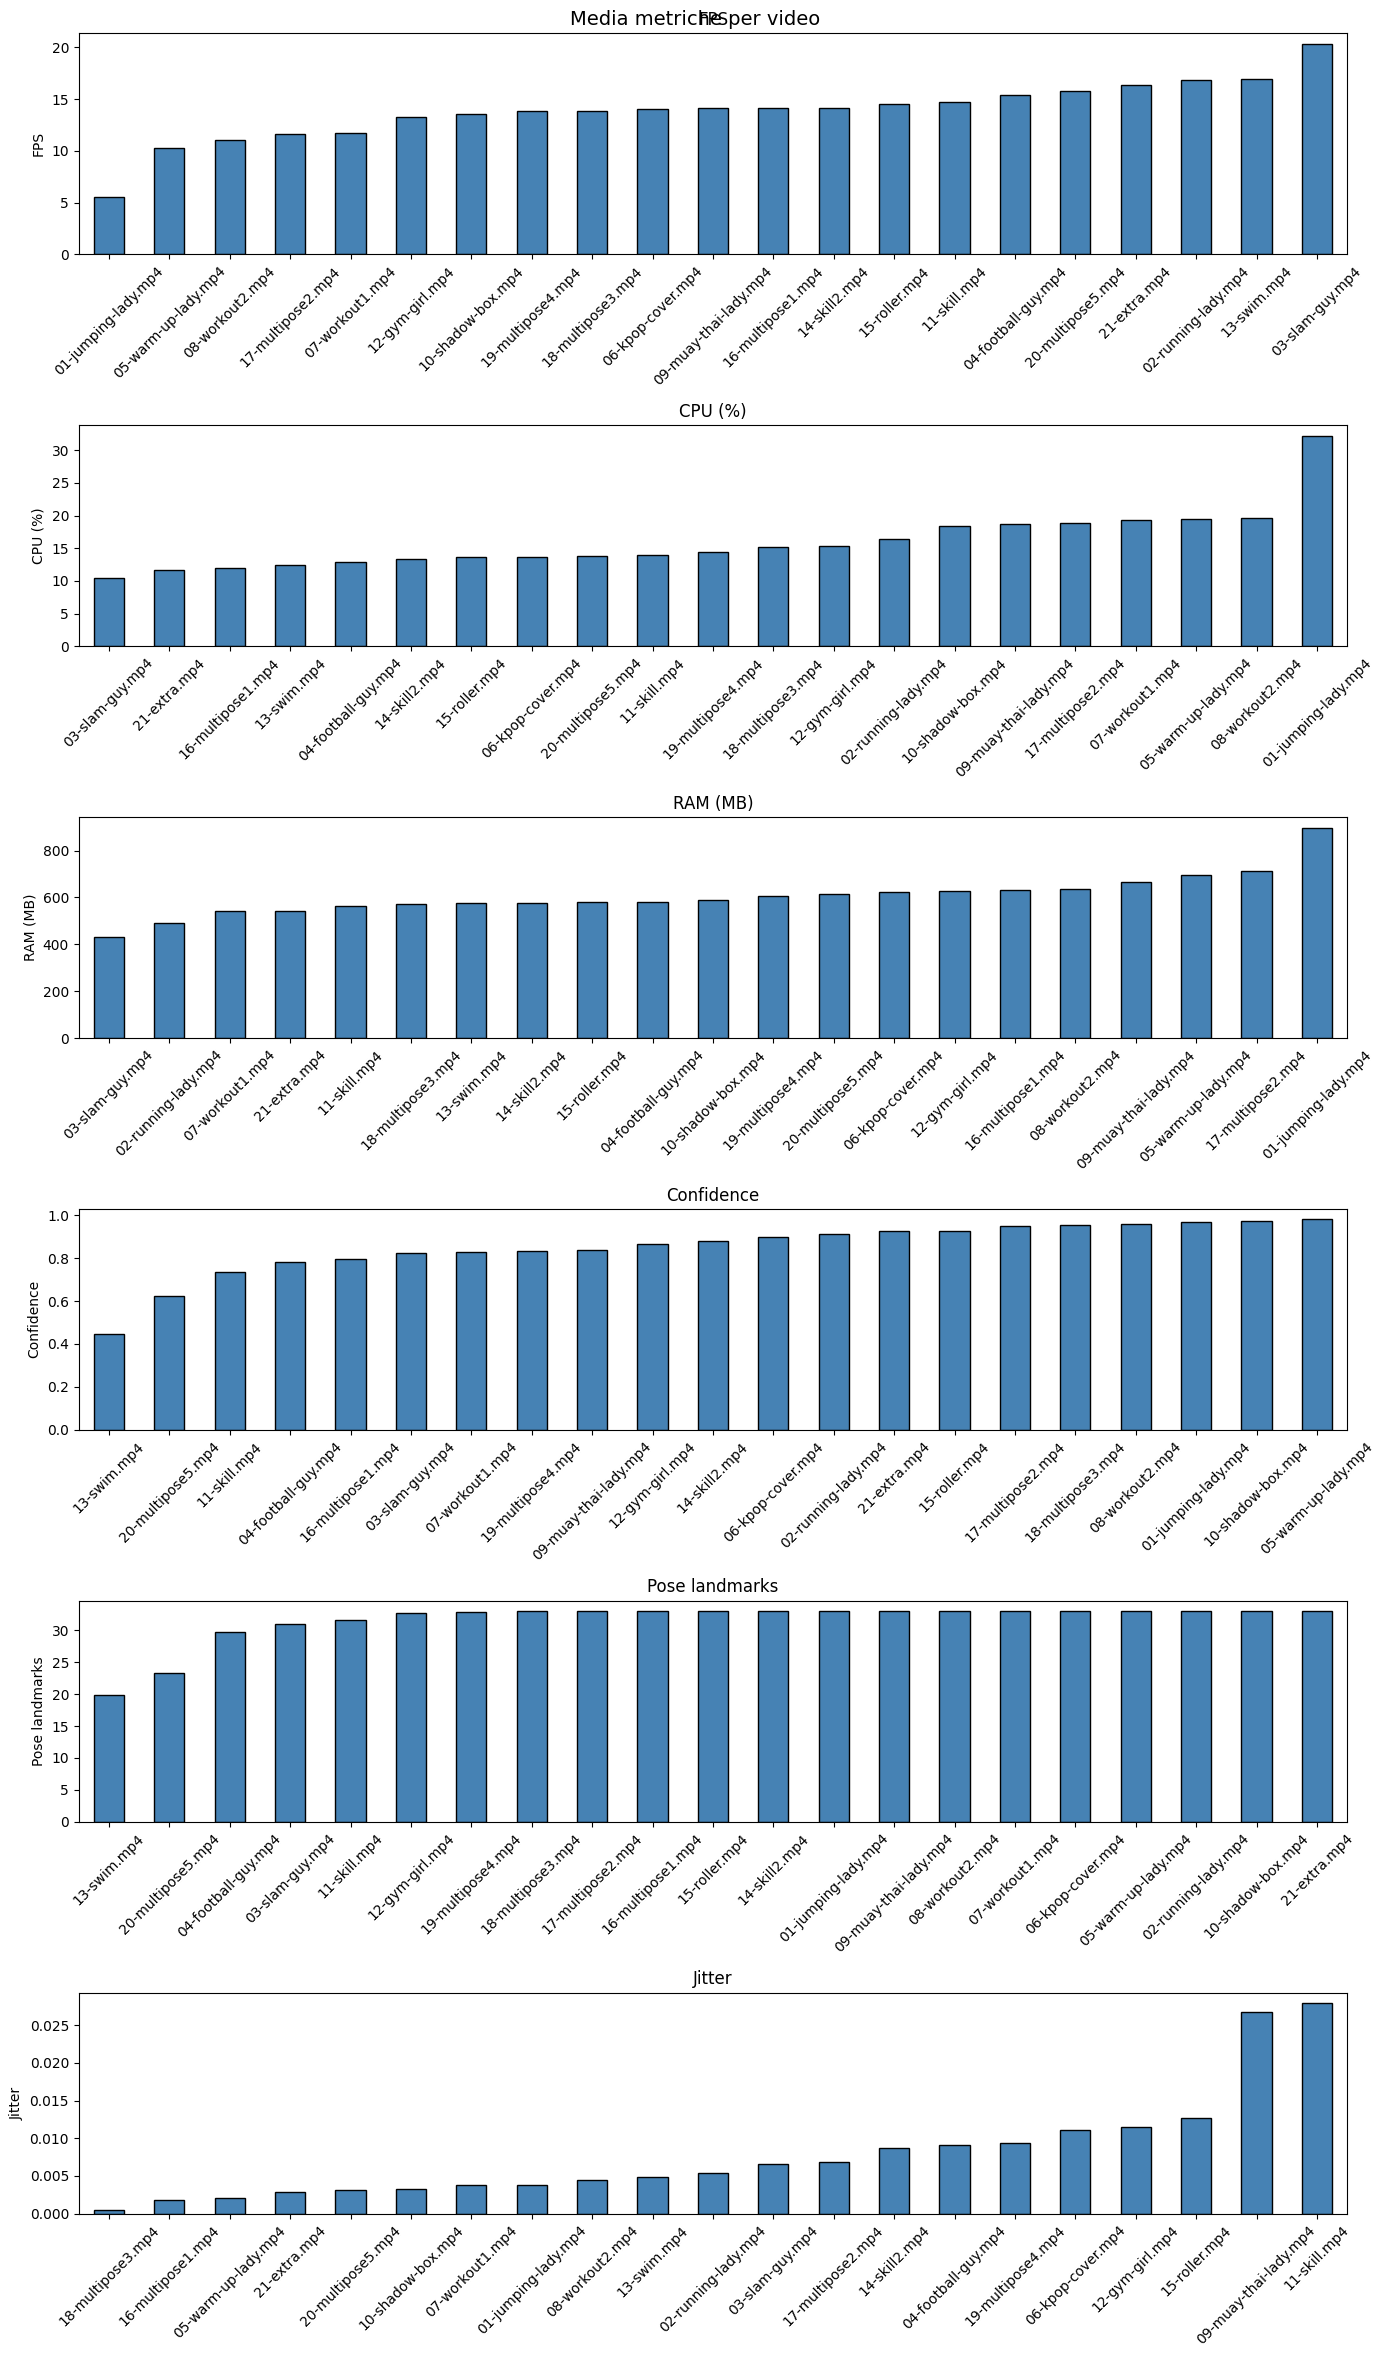

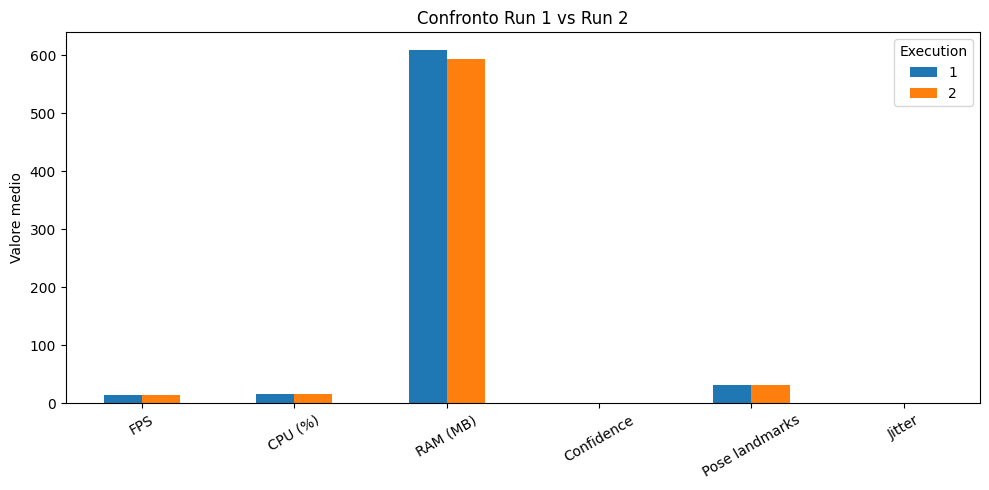

In [13]:
metrics = ['FPS', 'CPU (%)', 'RAM (MB)', 'Confidence', 'Pose landmarks', 'Jitter']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))
fig.suptitle("Media metriche per video", fontsize=14)

for ax, metric in zip(axes, metrics):
    means = df.groupby('Video name')[metric].mean().sort_values()
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("metrics_mean_overview.png", dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: confronto Run 1 vs Run 2
summary = df.groupby("Execution")[metrics].mean().round(3)

summary.T.plot(kind="bar", figsize=(10, 5), title="Confronto Run 1 vs Run 2")
plt.ylabel("Valore medio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()